# 参数配置

In [ ]:
import os
from pathlib import Path

#数据集根目录d
DATASET_ROOT = Path("./link-to-anime")          # 包含 train/ val/ test/ 的根目录

#  output
COCO_JSON_PREFIX = "./anime_coco"         # 生成 anime_coco_train.json / _val.json
# WORK_DIR         = "./work_dirs/anime_rtmpose_tiny"
WORK_DIR         = "./work_dirs/anime_rtmpose_large"

# model
# MODEL_CONFIG_NAME = "rtmpose-t_8xb256-420e_coco-256x192.py"
# RTMPOSE_MODEL_CONFIG = f"./mmpose/configs/body_2d_keypoint/rtmpose/coco/{MODEL_CONFIG_NAME}"
# MODEL_CONFIG_NAME = "rtmpose-m_8xb256-420e_coco-256x192.py"
# WORK_DIR = "./work_dirs/anime_rtmpose_medium"
MODEL_CONFIG_NAME = "rtmpose-l_8xb256-420e_coco-384x288.py"
WORK_DIR = "./work_dirs/anime_rtmpose_large"

# 超参数
MAX_EPOCHS   = 10
BATCH_SIZE   = 8
LR           = 5e-4
VAL_INTERVAL = 5
INPUT_SIZE   = (288, 384)  # (height, width)，需与 config.py 中保持一致
DEVICE       = 'cuda:0'
RANDOM_SEED  = 42

#  COCO-17 关键点顺序（与数据对象 COCO17_ORDER 保持一致）
KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]

# 骨骼连接（for可视化，0-indexed）
SKELETON = [
    [15,13],[13,11],[16,14],[14,12],[11,12],
    [5,11],[6,12],[5,6],[5,7],[6,8],
    [7,9],[8,10],[1,2],[0,1],[0,2],
    [1,3],[2,4],[3,5],[4,6]
]

print(f"DATASET_ROOT : {DATASET_ROOT.resolve()}")
print(f"COCO prefix  : {COCO_JSON_PREFIX}")

DATASET_ROOT : /home/tvem/anime/AniPose2/link-to-anime
COCO prefix  : ./anime_coco


In [2]:
import sys
import json
import random
import numpy as np
from tqdm import tqdm

# MMPose setup
if os.path.exists('./mmpose'):
    sys.path.insert(0, os.path.abspath('./mmpose'))
else:
    print("mmpose directory not found.")

from mmengine import Config
from mmengine.runner import Runner
from mmpose.utils import register_all_modules
from PIL import Image
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display

# 数据对象体系
from anime_dataset import AnimePoseDataset, DatasetConfig, COCO17_ORDER

register_all_modules()
print("MMPose ready.")

/home/tvem/anaconda3/envs/mmpose/lib/python3.8/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
/home/tvem/anaconda3/envs/mmpose/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


MMPose ready.


# 生成标准 COCO JSON TODO:处理目录不全的情况

数据已通过 `to_coco17()` + `save_json()` 持久化为每帧的 COCO-17 JSON。

这里直接用 `AnimePoseDataset` 遍历各 split，读取已有的 `coco_json_out_path`，汇总成 MMPose 所需的整体 COCO annotation 文件。

- `train` split → `anime_coco_train.json`
- `val` split   → `anime_coco_val.json`

In [3]:
def build_coco_json_from_dataset(
    ds: AnimePoseDataset,
    split: str,
    out_path: str,
    exported_subdir: str = "exported_coco17",   # ← 改这里
) -> str:
    """
    从 AnimePoseDataset 的指定 split 中读取已持久化的 COCO-17 JSON，
    汇总为 MMPose 需要的单一 COCO annotation 文件。

    每帧的 coco_json_out_path 必须已存在（即已完成 to_coco17 + save_json 工序）。
    返回写入的文件路径。
    """
    images, annotations = [], []
    missing = []

    for frame in tqdm(ds.iter_frames(split=split), desc=f"[{split}] assembling COCO JSON"):
        json_path = frame.coco_json_out_path
        if json_path is None or not Path(json_path).exists():
            missing.append(frame.sample_key)
            continue

        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # image_id：用整型 hash（uuid int 截断）保证唯一，也可直接用递增 id
        image_id = len(images) + 1

        # ── images 条目 ────────────────────────────────────────────────
        img_size = data.get("image_size")        # [w, h] 或 None
        images.append(dict(
            id          = image_id,
            file_name   = data["image_path"],    # 相对 dataset_root 的 posix 路径
            width       = img_size[0] if img_size else 0,
            height      = img_size[1] if img_size else 0,
        ))

        # ── annotations 条目 ───────────────────────────────────────────
        bbox = data.get("bbox") or [0.0, 0.0, 0.0, 0.0]   # [x, y, w, h]
        kps_flat = data.get("keypoints_flat")               # [x,y,v, x,y,v, ...]

        # 若没有 keypoints_flat，从 keypoints dict 重建
        if kps_flat is None:
            kps_dict = data.get("keypoints", {})
            kps_flat = []
            for name in COCO17_ORDER:
                kp = kps_dict.get(name, {"x": 0.0, "y": 0.0, "visibility": 0})
                kps_flat.extend([kp["x"], kp["y"], kp["visibility"]])

        num_keypoints = data.get("num_keypoints") or sum(
            1 for i in range(2, len(kps_flat), 3) if kps_flat[i] > 0
        )

        annotations.append(dict(
            id            = image_id,
            image_id      = image_id,
            category_id   = 1,
            bbox          = bbox,
            area          = bbox[2] * bbox[3],
            iscrowd       = 0,
            keypoints     = kps_flat,
            num_keypoints = num_keypoints,
        ))

    if missing:
        print(f"[WARN] {len(missing)} frames missing coco_json, skipped. First: {missing[0]}")

    coco_dict = dict(
        info        = dict(description=f"AnimePoseDataset {split}", version="1.0"),
        licenses    = [],
        images      = images,
        annotations = annotations,
        categories  = [dict(
            id             = 1,
            name           = "person",
            supercategory  = "person",
            keypoints      = KEYPOINT_NAMES,
            skeleton       = SKELETON,
        )],
    )

    out_path = str(out_path)
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(coco_dict, f, ensure_ascii=False)

    print(f"  [{split}] {len(images)} images, {len(annotations)} annotations → {out_path}")
    return out_path


# ── 初始化数据集对象 ───────────────────────────────────────────────────
ds = AnimePoseDataset(root=DATASET_ROOT, config=DatasetConfig(), debug=False)

train_anno_file = build_coco_json_from_dataset(ds, "train", f"{COCO_JSON_PREFIX}_train.json")
# val_anno_file   = build_coco_json_from_dataset(ds, "val",   f"{COCO_JSON_PREFIX}_val.json")
val_anno_file = build_coco_json_from_dataset(
    ds, "test", "./anime_coco_val.json", exported_subdir="exported_coco17"
)


print(f"\n训练集: {train_anno_file}")
print(f"验证集: {val_anno_file}")

[train] assembling COCO JSON: 360it [00:00, 441.59it/s]


  [train] 360 images, 360 annotations → ./anime_coco_train.json


[test] assembling COCO JSON: 360it [00:01, 311.60it/s]

  [test] 360 images, 360 annotations → ./anime_coco_val.json

训练集: ./anime_coco_train.json
验证集: ./anime_coco_val.json


## 转换后骨骼可视化预览

使用 `ipywidgets` 交互式控件，支持切换 train/val、随机种子、样本数等。

In [4]:
TRAIN_JSON     = Path(f"{COCO_JSON_PREFIX}_train.json")
VAL_JSON       = Path(f"{COCO_JSON_PREFIX}_val.json")
CHECK_IMG_PATH = False

COCO17_SKELETON_0IDX = [
    (15,13),(13,11),(16,14),(14,12),(11,12),
    (5,11),(6,12),(5,6),(5,7),(6,8),
    (7,9),(8,10),(1,2),(0,1),(0,2),
    (1,3),(2,4),(3,5),(4,6),
]
LIMB_COLORS = [
    "#FF6B6B","#FF6B6B","#4ECDC4","#4ECDC4","#45B7D1",
    "#96CEB4","#96CEB4","#FFEAA7","#DDA0DD","#DDA0DD",
    "#DDA0DD","#DDA0DD","#FFB347","#FFB347","#FFB347",
    "#87CEEB","#87CEEB","#87CEEB","#87CEEB",
]
KPT_COLOR_VISIBLE   = "#FF4500"
KPT_COLOR_INVISIBLE = "#999999"
COCO17_SHORT = [
    "nose","l_eye","r_eye","l_ear","r_ear",
    "l_sho","r_sho","l_elb","r_elb","l_wri","r_wri",
    "l_hip","r_hip","l_kne","r_kne","l_ank","r_ank",
]


def _load_coco_index(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {ann["image_id"]: ann for ann in coco["annotations"]}
    return {"img": img_map, "ann": ann_map, "ids": sorted(img_map.keys())}


def _draw_sample(ax, base_dir, img_info, ann,
                 show_invisible=False, show_labels=True):
    img_path = Path(base_dir) / img_info["file_name"]
    if CHECK_IMG_PATH:
        print(img_path.resolve())
    try:
        ax.imshow(np.array(Image.open(img_path).convert("RGB")))
    except Exception as e:
        ax.set_facecolor("#222")
        ax.text(0.5, 0.5, f"图像加载失败\n{e}", color="white",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)

    bbox = ann.get("bbox")
    if bbox and bbox[2] > 0 and bbox[3] > 0:
        ax.add_patch(mpatches.Rectangle(
            (bbox[0], bbox[1]), bbox[2], bbox[3],
            linewidth=2, edgecolor="#00FF7F", facecolor="none", zorder=4
        ))

    kps  = ann.get("keypoints", [])
    pts  = [(kps[i*3], kps[i*3+1], int(kps[i*3+2])) for i in range(len(kps)//3)]

    for idx, (a, b) in enumerate(COCO17_SKELETON_0IDX):
        if a < len(pts) and b < len(pts):
            xa, ya, va = pts[a]
            xb, yb, vb = pts[b]
            if va > 0 and vb > 0:
                ax.plot([xa, xb], [ya, yb],
                        color=LIMB_COLORS[idx] if idx < len(LIMB_COLORS) else "#FFF",
                        linewidth=2, zorder=3)

    for i, (x, y, v) in enumerate(pts):
        if v == 2:
            ax.scatter(x, y, s=40, c=KPT_COLOR_VISIBLE, zorder=5)
            if show_labels:
                lbl = COCO17_SHORT[i] if i < len(COCO17_SHORT) else str(i)
                ax.text(x+4, y-4, lbl, fontsize=7, color=KPT_COLOR_VISIBLE,
                        bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.5), zorder=6)
        elif v == 0 and show_invisible:
            ax.scatter(x, y, s=20, c=KPT_COLOR_INVISIBLE, marker="x", zorder=5)

    n_vis = sum(1 for _,_,v in pts if v == 2)
    ax.set_title(
        f"id={img_info['id']}  vis={n_vis}/{len(pts)}\n{Path(img_info['file_name']).name}",
        fontsize=9
    )
    ax.axis("off")


def visualize_coco_samples(
    json_path, base_dir, num_samples=6, cols=3,
    random_seed=0, show_invisible=False, show_labels=True,
):
    idx  = _load_coco_index(json_path)
    random.seed(random_seed)
    ids  = random.sample(idx["ids"], min(num_samples, len(idx["ids"])))
    rows = (len(ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*6))
    axes = np.array(axes).flatten()
    for i, img_id in enumerate(ids):
        _draw_sample(axes[i], base_dir, idx["img"][img_id], idx["ann"].get(img_id, {}),
                     show_invisible=show_invisible, show_labels=show_labels)
    for i in range(len(ids), len(axes)):
        axes[i].axis("off")
    split_tag = "TRAIN" if "train" in Path(json_path).name else "VAL"
    fig.suptitle(
        f"[{split_tag}] {json_path}  |  {len(idx['ids'])} samples total",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.show()


def _make_validator_widget(base_dir, train_json, val_json):
    split_toggle = widgets.ToggleButtons(options=["train", "val"], description="Split")
    seed_slider  = widgets.IntSlider(value=0, min=0, max=99, description="Seed")
    n_slider     = widgets.IntSlider(value=6, min=1, max=24, description="Samples")
    cols_slider  = widgets.IntSlider(value=3, min=1, max=6,  description="Cols")
    inv_check    = widgets.Checkbox(value=False, description="Show OOF pts")
    lbl_check    = widgets.Checkbox(value=True,  description="Show labels")
    ui = widgets.VBox([
        widgets.HBox([split_toggle, seed_slider]),
        widgets.HBox([n_slider, cols_slider, inv_check, lbl_check]),
    ])
    def _run(split, seed, n, cols, show_inv, show_lbl):
        json_path = str(train_json) if split == "train" else str(val_json)
        visualize_coco_samples(json_path, base_dir, n, cols, seed, show_inv, show_lbl)
    out = widgets.interactive_output(_run, {
        "split": split_toggle, "seed": seed_slider, "n": n_slider,
        "cols": cols_slider, "show_inv": inv_check, "show_lbl": lbl_check,
    })
    display(ui, out)


_make_validator_widget(str(DATASET_ROOT), TRAIN_JSON, VAL_JSON)

Output()

# 训练配置

In [ ]:
import warnings


train_anno_file = os.path.abspath(train_anno_file)
val_anno_file   = os.path.abspath(val_anno_file)
print(f"train: {train_anno_file}")
print(f"val:   {val_anno_file}")


SIGMA = 6.0  # RTMPose family 默认高斯平滑

assert 'train_anno_file' in globals(), "请先运行上方 Cell 生成 COCO JSON"

config_full_path = os.path.join(
    './mmpose/configs/body_2d_keypoint/rtmpose/coco',
    MODEL_CONFIG_NAME
)

cfg = Config.fromfile(config_full_path)

mmpose_root  = os.path.abspath('./mmpose/configs')
cfg.work_dir  = WORK_DIR
cfg.data_root = str(DATASET_ROOT.resolve())

train_pipeline = [
    dict(type='LoadImage', file_client_args=dict(backend='disk')),
    dict(type='GetBBoxCenterScale'),
    dict(type='RandomFlip', direction='horizontal', prob=0.5),
    dict(type='RandomBBoxTransform', scale_factor=[0.75, 1.25], shift_factor=0.1),
    dict(type='TopdownAffine', input_size=INPUT_SIZE, use_udp=True),
    dict(type='GenerateTarget', encoder=dict(
        type='SimCCLabel', input_size=INPUT_SIZE,
        smoothing_type='gaussian', sigma=SIGMA,
        simcc_split_ratio=2.0, label_smooth_weight=0.0,
    )),
    dict(type='PackPoseInputs')
]
test_pipeline = [
    dict(type='LoadImage', file_client_args=dict(backend='disk')),
    dict(type='GetBBoxCenterScale'),
    dict(type='TopdownAffine', input_size=INPUT_SIZE, use_udp=True),
    dict(type='PackPoseInputs')
]

common_ds_kwargs = dict(
    data_root   = cfg.data_root,
    data_prefix = dict(img=''),
    metainfo    = dict(from_file=os.path.join(mmpose_root, '_base_/datasets/coco.py')),
)


# dataloader 和 evaluator 的配置较冗长，单独列出
cfg.train_dataloader = dict(
    batch_size=BATCH_SIZE, num_workers=4, persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    dataset=dict(type='CocoDataset', ann_file=train_anno_file,
                 pipeline=train_pipeline, **common_ds_kwargs)
)
cfg.val_dataloader = dict(
    batch_size=BATCH_SIZE, num_workers=4, persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(type='CocoDataset', ann_file=val_anno_file,
                 pipeline=test_pipeline, test_mode=True, **common_ds_kwargs)
)
cfg.test_dataloader = cfg.val_dataloader

cfg.val_evaluator  = dict(type='CocoMetric', ann_file=val_anno_file,
                          score_mode='keypoint', nms_mode='none')
cfg.test_evaluator = cfg.val_evaluator

cfg.optim_wrapper = dict(
    type='OptimWrapper',
    optimizer=dict(type='AdamW', lr=LR, betas=(0.9, 0.999), weight_decay=0.01),
    paramwise_cfg=dict(norm_decay_mult=0, bias_decay_mult=0, bypass_duplicate=True),
)
cfg.train_cfg     = dict(type='EpochBasedTrainLoop', max_epochs=MAX_EPOCHS, val_interval=VAL_INTERVAL)
cfg.param_scheduler = [
    dict(type='LinearLR', start_factor=0.001, by_epoch=False, begin=0, end=500),
    dict(type='MultiStepLR',
         milestones=[int(MAX_EPOCHS*0.7), int(MAX_EPOCHS*0.9)], gamma=0.1),
]
cfg.default_hooks = dict(
    timer           = dict(type='IterTimerHook'),
    logger          = dict(type='LoggerHook', interval=10),
    param_scheduler = dict(type='ParamSchedulerHook'),
    checkpoint      = dict(type='CheckpointHook', interval=VAL_INTERVAL,
                           save_best='coco/AP', rule='greater', max_keep_ckpts=3),
    sampler_seed    = dict(type='DistSamplerSeedHook'),
)
cfg.visualizer = dict(type='PoseLocalVisualizer',
                      vis_backends=[dict(type='LocalVisBackend')], name='visualizer')

cfg.model.head.decoder = dict(
    type='SimCCLabel', input_size=INPUT_SIZE,
    smoothing_type='gaussian', sigma=SIGMA, simcc_split_ratio=2.0,
)

os.makedirs(WORK_DIR, exist_ok=True)
cfg.dump(os.path.join(WORK_DIR, 'config.py'))

print(f"配置完成,SimCCLabel;(sigma={SIGMA})")
print(f"  输入尺寸  : {INPUT_SIZE}")
print(f"  train: {len(json.load(open(train_anno_file))['images'])}")
print(f"  val: {len(json.load(open(val_anno_file))['images'])}")

train: /home/tvem/anime/AniPose2/anime_coco_train.json
val:   /home/tvem/anime/AniPose2/anime_coco_val.json
配置完成: RTMPose-tiny + SimCCLabel (sigma=6.0)
  输入尺寸  : (192, 256)
  训练样本数: 360
  验证样本数: 360


# 微调

In [7]:
import os, sys, functools, warnings

def suppress_libpng_warnings(func):
    """压制 libpng C 层警告（如 eXIf: duplicate）及 torch FutureWarning。"""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=".*eXIf.*")
            warnings.filterwarnings("ignore", category=FutureWarning, message=".*weights_only.*")
            devnull_fd   = os.open(os.devnull, os.O_WRONLY)
            old_stderr   = os.dup(2)
            os.dup2(devnull_fd, 2)
            os.close(devnull_fd)
            try:
                result = func(*args, **kwargs)
            finally:
                os.dup2(old_stderr, 2)
                os.close(old_stderr)
        return result
    return wrapper

In [8]:
runner = Runner.from_cfg(cfg)
print("\n开始训练...")
runner.train()

03/31 00:37:02 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.8.4 | packaged by conda-forge | (default, Jul 17 2020, 15:16:46) [GCC 7.5.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 21
    GPU 0: NVIDIA GeForce RTX 2080 Ti
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.0, V12.0.140
    GCC: gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
    PyTorch: 2.4.1+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.4.2 (Git Hash 1137e04ec0b5251ca2b4400a4fd3c667ce843d67)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=comput

Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/cspnext-l_udp-aic-coco_210e-256x192-273b7631_20230130.pth" to /home/tvem/.cache/torch/hub/checkpoints/cspnext-l_udp-aic-coco_210e-256x192-273b7631_20230130.pth


03/31 00:37:10 - mmengine - WARNING - "FileClient" will be deprecated in future. Please use io functions in https://mmengine.readthedocs.io/en/latest/api/fileio.html#file-io
03/31 00:37:10 - mmengine - WARNING - "HardDiskBackend" is the alias of "LocalBackend" and the former will be deprecated in future.
03/31 00:37:10 - mmengine - INFO - Checkpoints will be saved to /home/tvem/anime/AniPose2/work_dirs/anime_rtmpose_large.


libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng w

03/31 00:37:18 - mmengine - INFO - Epoch(train)  [1][10/45]  base_lr: 9.509018e-06 lr: 9.509018e-06  eta: 0:05:24  time: 0.736623  data_time: 0.198817  memory: 1382  loss: 0.000476  loss_kpt: 0.000476  acc_pose: 0.016807


...

libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng w

03/31 00:40:38 - mmengine - INFO - Epoch(val) [10][40/45]    eta: 0:00:01  time: 0.283209  data_time: 0.168570  memory: 562  


libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate
libpng warning: eXIf: duplicate


03/31 00:40:38 - mmengine - INFO - Evaluating CocoMetric...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *keypoints*
DONE (t=0.10s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets= 20 ] =  0.380
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets= 20 ] =  0.860
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets= 20 ] =  0.241
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets= 20 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets= 20 ] =  0.380
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 20 ] =  0.426
 Average Recall     (AR) @[ IoU=0.50      | area=   all | maxDets= 20 ] =  0.883
 Average Recall     (AR) @[ IoU=0.75      | area=   all | maxDets= 20 ] =  0.361
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets= 20 ] = -

TopdownPoseEstimator(
  (data_preprocessor): PoseDataPreprocessor()
  (backbone): CSPNeXt(
    (stem): Sequential(
      (0): ConvModule(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): _BatchNormXd(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activate): SiLU(inplace=True)
      )
      (1): ConvModule(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): _BatchNormXd(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activate): SiLU(inplace=True)
      )
      (2): ConvModule(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): _BatchNormXd(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activate): SiLU(inplace=True)
      )
    )
    (stage1): Sequential(
      (0): ConvModule(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), st

In [12]:
import json
with open(val_anno_file) as f:
    val = json.load(f)
print(f"images: {len(val['images'])}")
print(f"annotations: {len(val['annotations'])}")
if val['images']:
    print("第一条 image:", val['images'][0])
    print("第一条 ann:", val['annotations'][0] if val['annotations'] else 'EMPTY')

images: 360
annotations: 360
第一条 image: {'id': 1, 'file_name': 'test/color_line_optic_68_80/68 model/01 visual_view/01_1 Rendering/0001_1.png', 'width': 2560, 'height': 1440}
第一条 ann: {'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [810, 389, 707, 1051], 'area': 743057, 'iscrowd': 0, 'keypoints': [1174.6085067325168, 662.7132822672527, 2, 1199.2885627746582, 616.8788938522339, 2, 1195.7628404829238, 616.8788938522339, 2, 1296.2459257973564, 618.6417549451191, 2, 1271.565869755215, 620.4046160380046, 2, 1420.1843804738492, 878.496356078842, 2, 1192.763831451044, 853.3267539889122, 2, 1408.1649115605799, 1104.2914389150417, 2, 1078.9275000569871, 1015.4783414384009, 2, 1122.3798771471038, 1015.7752259626631, 2, 895.5417995776698, 878.8144919854499, 2, 1388.4138403961742, 1259.6852204020533, 2, 1260.688319682198, 1237.3252858594933, 2, 1443.1464634357892, 1766.2542012299853, 0, 1011.4488847267913, 1663.4251612194046, 0, 1769.3173240179444, 2130.5664021872417, 0, 962.0318434289209, 2055

In [13]:
import json, os

for p in [train_anno_file, val_anno_file]:
    print("=" * 80)
    print("FILE:", p, "exists:", os.path.exists(p))
    with open(p, "r", encoding="utf-8") as f:
        d = json.load(f)
    print("images:", len(d.get("images", [])))
    print("annotations:", len(d.get("annotations", [])))
    if d.get("images"):
        print("first image:", d["images"][0])
    if d.get("annotations"):
        print("first ann keys:", d["annotations"][0].keys())
        print("first ann bbox:", d["annotations"][0].get("bbox"))
        print("first ann num_keypoints:", d["annotations"][0].get("num_keypoints"))

FILE: /home/tvem/anime/AniPose2/anime_coco_train.json exists: True
images: 360
annotations: 360
first image: {'id': 1, 'file_name': 'train/color_line_optic_26_45/26 model/01 visual_view/01_1 Rendering/0001_1.png', 'width': 2560, 'height': 1440}
first ann keys: dict_keys(['id', 'image_id', 'category_id', 'bbox', 'area', 'iscrowd', 'keypoints', 'num_keypoints'])
first ann bbox: [600, 132, 726, 1308]
first ann num_keypoints: 13
FILE: /home/tvem/anime/AniPose2/anime_coco_val.json exists: True
images: 360
annotations: 360
first image: {'id': 1, 'file_name': 'test/color_line_optic_68_80/68 model/01 visual_view/01_1 Rendering/0001_1.png', 'width': 2560, 'height': 1440}
first ann keys: dict_keys(['id', 'image_id', 'category_id', 'bbox', 'area', 'iscrowd', 'keypoints', 'num_keypoints'])
first ann bbox: [810, 389, 707, 1051]
first ann num_keypoints: 13


## 训练指标展示

读取: work_dirs/anime_rtmpose_large/20260331_003701/vis_data/scalars.json


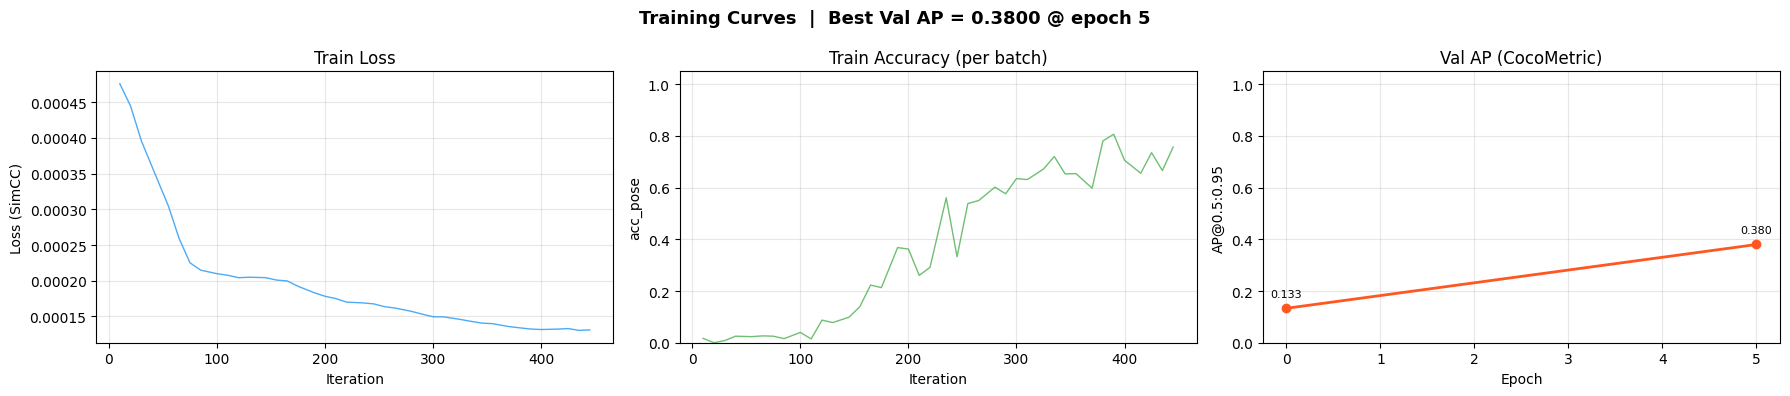

验证次数: 2
最终 loss  : 0.000131
最佳 Val AP: 0.3800 @ epoch 5


In [14]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# 自动找最新的 scalars.json
scalars_candidates = sorted(
    Path(WORK_DIR).glob("*/vis_data/scalars.json"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not scalars_candidates:
    raise FileNotFoundError(f"找不到 scalars.json，请检查 WORK_DIR: {WORK_DIR}")
scalars_path = scalars_candidates[0]
print(f"读取: {scalars_path}")

with open(scalars_path) as f:
    lines = [json.loads(l) for l in f if l.strip()]

train_iters, train_loss, train_acc = [], [], []
val_epochs, val_ap = [], []

for entry in lines:
    if "loss" in entry and "coco/AP" not in entry:
        train_iters.append(entry.get("iter", len(train_iters)))
        train_loss.append(entry["loss"])
        if "acc_pose" in entry:
            train_acc.append(entry["acc_pose"])
    if "coco/AP" in entry:
        val_epochs.append(entry.get("epoch", len(val_epochs) * VAL_INTERVAL))
        val_ap.append(entry["coco/AP"])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(train_iters, train_loss, color="#2196F3", linewidth=1, alpha=0.8)
axes[0].set(xlabel="Iteration", ylabel="Loss (SimCC)", title="Train Loss")
axes[0].grid(alpha=0.3)

if train_acc:
    axes[1].plot(train_iters[:len(train_acc)], train_acc, color="#4CAF50", linewidth=1, alpha=0.8)
axes[1].set(xlabel="Iteration", ylabel="acc_pose", title="Train Accuracy (per batch)")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

axes[2].plot(val_epochs, val_ap, color="#FF5722", marker="o", linewidth=2, markersize=6)
axes[2].set(xlabel="Epoch", ylabel="AP@0.5:0.95", title="Val AP (CocoMetric)")
axes[2].set_ylim(0, 1.05)
axes[2].grid(alpha=0.3)
for ep, ap in zip(val_epochs, val_ap):
    axes[2].annotate(f"{ap:.3f}", (ep, ap), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

best_ap = max(val_ap)
best_ep = val_epochs[val_ap.index(best_ap)]
fig.suptitle(f"Training Curves  |  Best Val AP = {best_ap:.4f} @ epoch {best_ep}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"验证次数: {len(val_epochs)}")
print(f"最终 loss  : {train_loss[-1]:.6f}")
print(f"最佳 Val AP: {best_ap:.4f} @ epoch {best_ep}")

# 结果可视化 & 对比 Baseline
- 左侧：Baseline（微调前）预测
- 右侧：Fine-tuned（微调后）预测